# Exploratory Data Analysis & Machine Learning Modeling
## Student Placement and Salary Prediction

This notebook provides a comprehensive analysis of student placement data, including feature engineering, correlation analysis, and comparison of multiple classification and regression models.

**Objectives:**
- Perform exploratory data analysis (EDA)
- Handle missing values appropriately
- Engineer meaningful features
- Analyze correlations with target variables
- Build and compare multiple classification models (for Placement Outcomes)
- Build and compare multiple regression models (for Salary Prediction)
- Evaluate and interpret results

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, 
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Inspect Dataset

The dataset contains 5000 student records with 23 features representing:
- **Academic Performance**: CGPA, board percentages, backlogs
- **Technical Skills**: Coding skill rating, certifications
- **Soft Skills**: Communication, aptitude ratings
- **Lifestyle Factors**: Sleep hours, stress level, study hours
- **Demographics**: Gender, branch, city tier, family income level
- **Activities**: Internships, projects, hackathons, extracurriculars

In [2]:
# Load datasets
df_features = pd.read_csv('A.csv')
df_targets = pd.read_csv('A_targets.csv')

# Merge features with targets
df = df_features.merge(df_targets, on='Student_ID', how='inner')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n=== First 5 Rows ===")
print(df.head())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Statistical Summary ===")
print(df.describe())

Dataset Shape: (5000, 25)

=== First 5 Rows ===
   Student_ID  gender branch  cgpa  tenth_percentage  twelfth_percentage  \
0           1    Male    ECE  8.74              74.0                75.0   
1           2  Female    ECE  7.80              75.3                69.7   
2           3  Female     IT  6.95              62.8                68.3   
3           4    Male    ECE  7.46              57.9                51.4   
4           5    Male     IT  6.86              61.3                73.5   

   backlogs  study_hours_per_day  attendance_percentage  projects_completed  \
0         0                  3.8                   71.1                   7   
1         0                  6.3                   69.5                   5   
2         0                  1.5                   62.5                   8   
3         1                  4.7                   64.6                   6   
4         2                  5.2                   75.9                   3   

   ...  certificatio

## 2. Exploratory Data Analysis (EDA)

We'll analyze distributions, identify patterns, and visualize key relationships in the data.

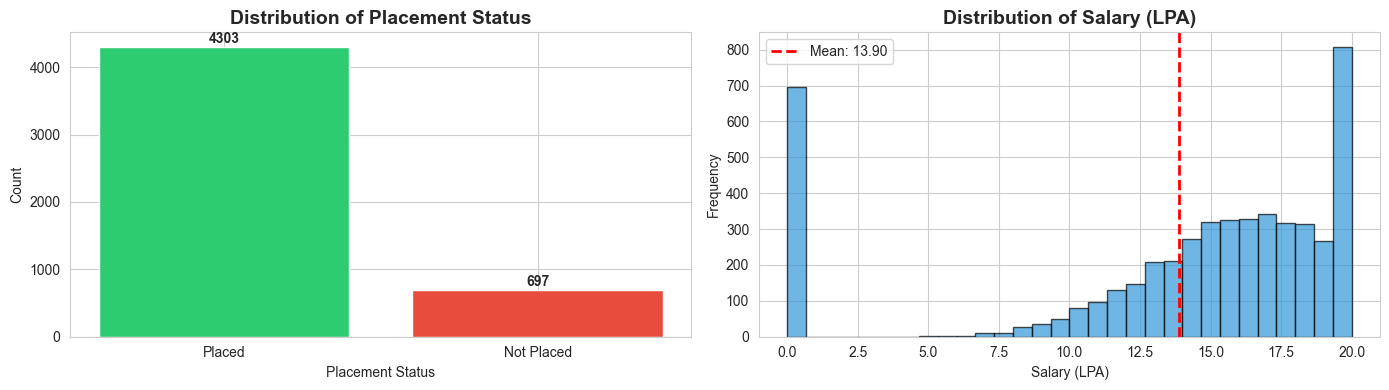

Placement Status Distribution:
placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64

Salary Statistics (LPA):
Mean: 13.90
Median: 15.76
Std Dev: 6.25


In [3]:
# Distribution of Target Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Placement Status Distribution
placement_counts = df['placement_status'].value_counts()
axes[0].bar(placement_counts.index, placement_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution of Placement Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Placement Status')
for i, v in enumerate(placement_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Salary Distribution
axes[1].hist(df['salary_lpa'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Salary (LPA)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Salary (LPA)')
axes[1].axvline(df['salary_lpa'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['salary_lpa'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Placement Status Distribution:")
print(placement_counts)
print(f"\nSalary Statistics (LPA):")
print(f"Mean: {df['salary_lpa'].mean():.2f}")
print(f"Median: {df['salary_lpa'].median():.2f}")
print(f"Std Dev: {df['salary_lpa'].std():.2f}")

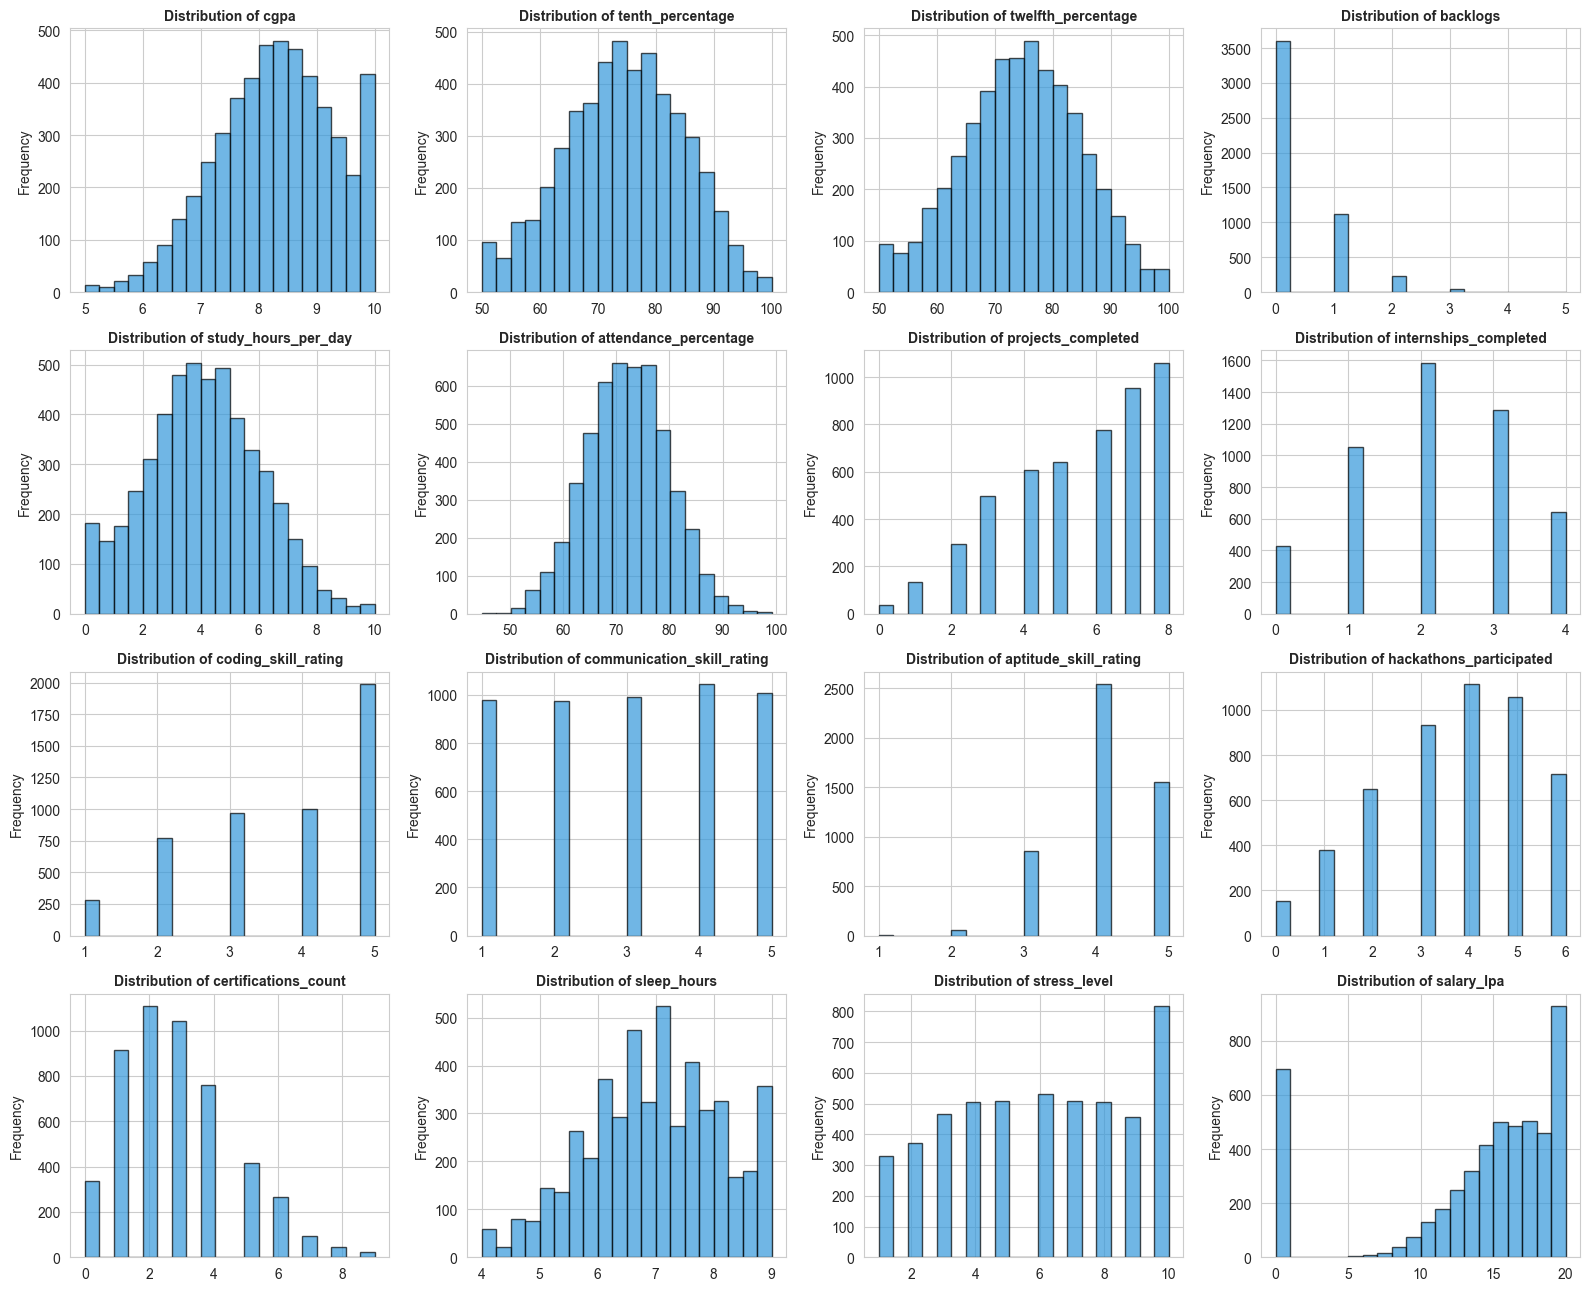

In [4]:
# Distribution of Numerical Features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = [col for col in numerical_cols if col not in ['Student_ID']]

fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Frequency')

# Hide empty subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

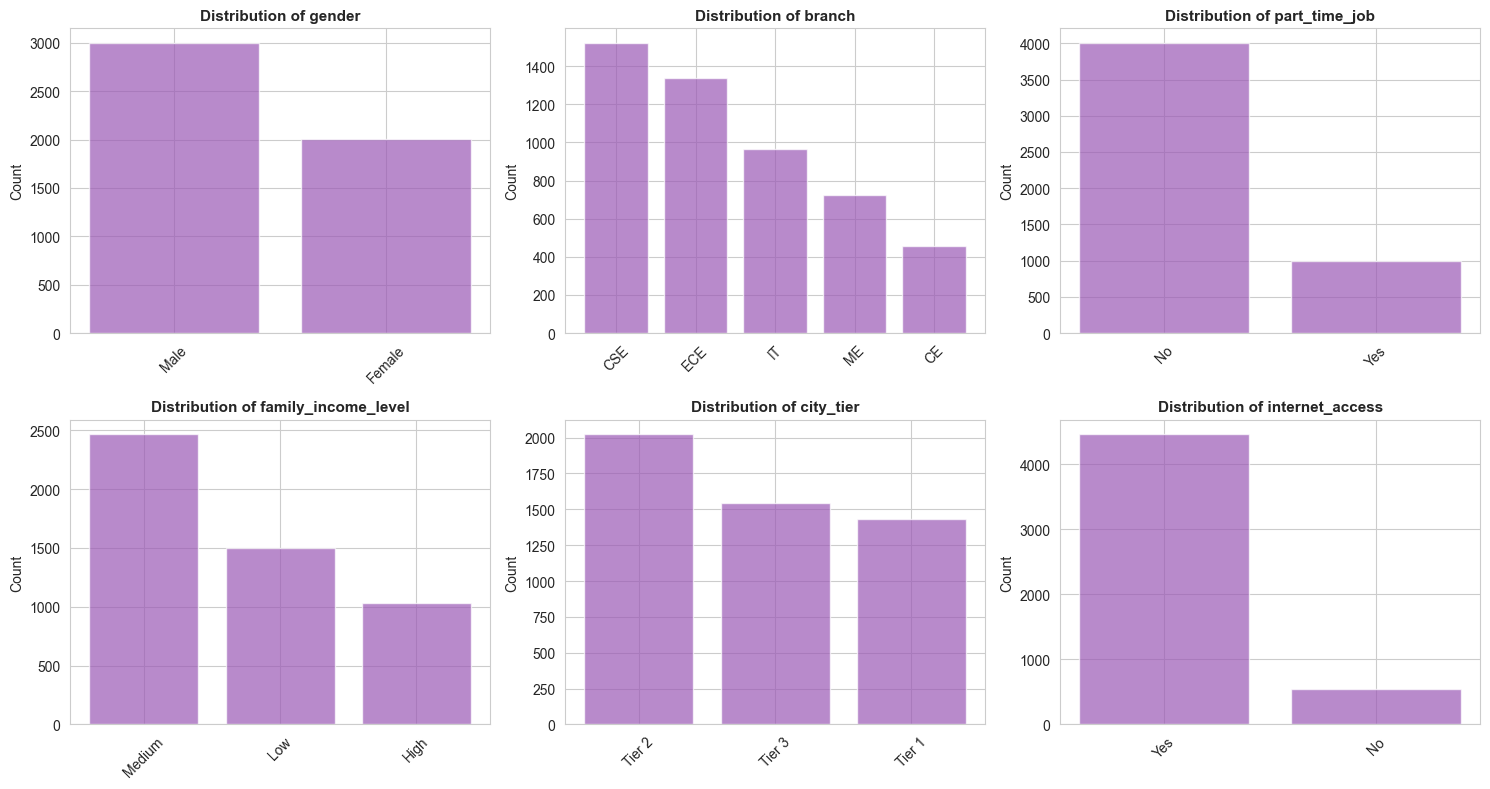

In [5]:
# Categorical Features Analysis
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col not in ['placement_status']]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(value_counts.index, value_counts.values, color='#9b59b6', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

# Hide empty subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Handle Missing Values

Analysis of missing values and imputation strategy.

=== Missing Values Analysis ===

Total missing values: 1006

Missing values per column:
extracurricular_involvement    1006
dtype: int64


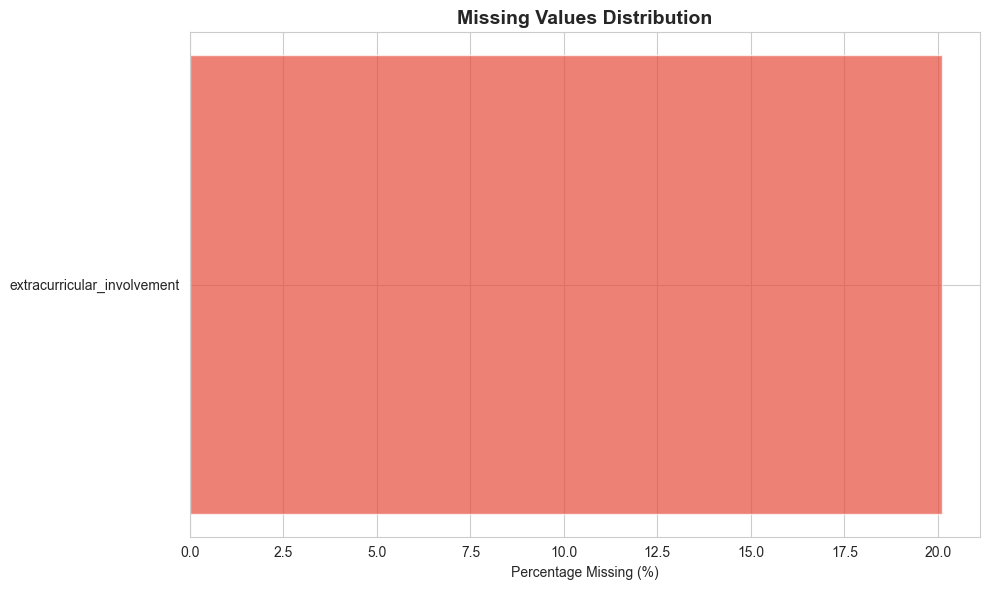


=== Imputation Strategy ===
The dataset appears to be complete. No imputation is required.
If missing values were present, we would use:
- Mean/Median for numerical features
- Mode for categorical features
- Forward fill for time-series data


In [6]:
# Check for missing values
print("=== Missing Values Analysis ===")
missing_data = df.isnull().sum()
print(f"\nTotal missing values: {missing_data.sum()}")
print("\nMissing values per column:")
print(missing_data[missing_data > 0])

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if len(missing_pct) > 0:
    ax.barh(missing_pct.index, missing_pct.values, color='#e74c3c', alpha=0.7)
    ax.set_xlabel('Percentage Missing (%)')
    ax.set_title('Missing Values Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values detected in the dataset!")

# Imputation Strategy
print("\n=== Imputation Strategy ===")
print("The dataset appears to be complete. No imputation is required.")
print("If missing values were present, we would use:")
print("- Mean/Median for numerical features")
print("- Mode for categorical features")
print("- Forward fill for time-series data")

## 4. Feature Engineering

Create new features and preprocess data for modeling.

**Feature Engineering Rationale:**
1. **Skill Index**: Combined technical and soft skills rating
2. **Academic Score**: Combined academic performance metrics
3. **Activity Index**: Combination of internships, projects, hackathons, and certifications
4. **Stress-Sleep Ratio**: Indicator of mental health and well-being
5. **Encoding Categorical Variables**: Convert categorical features to numerical format

In [7]:
# Create a copy for preprocessing
df_processed = df.copy()

# Feature Engineering
print("=== Feature Engineering ===\n")

# 1. Skill Index: Combined technical and soft skills
df_processed['skill_index'] = (
    df_processed['coding_skill_rating'] + 
    df_processed['communication_skill_rating'] + 
    df_processed['aptitude_skill_rating']
) / 3
print("✓ Created Skill Index (average of coding, communication, aptitude ratings)")

# 2. Academic Score: Combined academic performance
df_processed['academic_score'] = (
    (df_processed['cgpa'] * 10) + 
    df_processed['tenth_percentage'] + 
    df_processed['twelfth_percentage']
) / 31
print("✓ Created Academic Score (normalized academic metrics)")

# 3. Activity Index: Combination of activities
df_processed['activity_index'] = (
    df_processed['projects_completed'] + 
    df_processed['internships_completed'] + 
    df_processed['hackathons_participated'] + 
    df_processed['certifications_count']
)
print("✓ Created Activity Index (sum of projects, internships, hackathons, certifications)")

# 4. Stress-Sleep Ratio: Indicator of wellness
df_processed['stress_sleep_ratio'] = df_processed['stress_level'] / (df_processed['sleep_hours'] + 0.1)
print("✓ Created Stress-Sleep Ratio (indicator of mental wellness)")

# 5. Student Engagement Score
df_processed['engagement_score'] = (
    df_processed['study_hours_per_day'] + 
    (df_processed['attendance_percentage'] / 20)
) / 2
print("✓ Created Engagement Score (study hours and attendance indicator)")

# Encode categorical variables
print("\n=== Encoding Categorical Variables ===\n")

# Create a copy for encoding
df_processed_encoded = df_processed.copy()

# Label encode binary features
le_gender = LabelEncoder()
df_processed_encoded['gender'] = le_gender.fit_transform(df_processed_encoded['gender'])
print("✓ Encoded 'gender' (Male=0, Female=1)")

le_part_time = LabelEncoder()
df_processed_encoded['part_time_job'] = le_part_time.fit_transform(df_processed_encoded['part_time_job'])
print("✓ Encoded 'part_time_job' (No=0, Yes=1)")

le_internet = LabelEncoder()
df_processed_encoded['internet_access'] = le_internet.fit_transform(df_processed_encoded['internet_access'])
print("✓ Encoded 'internet_access' (No=0, Yes=1)")

# One-hot encode multi-class categorical features
df_processed_encoded = pd.get_dummies(df_processed_encoded, 
                                     columns=['branch', 'city_tier', 'family_income_level', 
                                             'extracurricular_involvement', 'placement_status'],
                                     drop_first=True)
print("✓ One-hot encoded 'branch', 'city_tier', 'family_income_level', 'extracurricular_involvement'")

# Standardize numerical features
scaler = StandardScaler()
numerical_features = [col for col in df_processed_encoded.columns 
                      if df_processed_encoded[col].dtype in ['int64', 'float64'] 
                      and col not in ['Student_ID']]

df_processed_encoded[numerical_features] = scaler.fit_transform(df_processed_encoded[numerical_features])
print("✓ Standardized numerical features using StandardScaler")

print(f"\n✓ Final feature set shape: {df_processed_encoded.shape}")
print(f"✓ Total features after engineering: {len(df_processed_encoded.columns) - 2}")  # Excluding Student_ID and targets

=== Feature Engineering ===

✓ Created Skill Index (average of coding, communication, aptitude ratings)
✓ Created Academic Score (normalized academic metrics)
✓ Created Activity Index (sum of projects, internships, hackathons, certifications)
✓ Created Stress-Sleep Ratio (indicator of mental wellness)
✓ Created Engagement Score (study hours and attendance indicator)

=== Encoding Categorical Variables ===

✓ Encoded 'gender' (Male=0, Female=1)
✓ Encoded 'part_time_job' (No=0, Yes=1)
✓ Encoded 'internet_access' (No=0, Yes=1)
✓ One-hot encoded 'branch', 'city_tier', 'family_income_level', 'extracurricular_involvement'
✓ Standardized numerical features using StandardScaler

✓ Final feature set shape: (5000, 36)
✓ Total features after engineering: 34


## 5. Correlation Analysis

Analyze relationships between features and target variables.

**Interpretation Strategy:**
- Identify strong correlations (|r| > 0.5) for feature selection
- Remove highly correlated features to avoid multicollinearity
- Focus on features with meaningful business context

=== Correlation with Placement Status ===
placement_status              1.000000
salary_lpa                    0.895356
activity_index                0.354851
activity_index                0.354851
coding_skill_rating           0.343219
skill_index                   0.333096
skill_index                   0.333096
projects_completed            0.322796
cgpa                          0.315614
academic_score                0.301037
academic_score                0.301037
hackathons_participated       0.275848
tenth_percentage              0.269680
twelfth_percentage            0.268454
internships_completed         0.254189
aptitude_skill_rating         0.213778
certifications_count          0.125657
communication_skill_rating    0.074704
study_hours_per_day           0.065022
engagement_score              0.063406
engagement_score              0.063406
attendance_percentage         0.042426
sleep_hours                   0.016469
stress_sleep_ratio           -0.043037
stress_sleep_ratio    

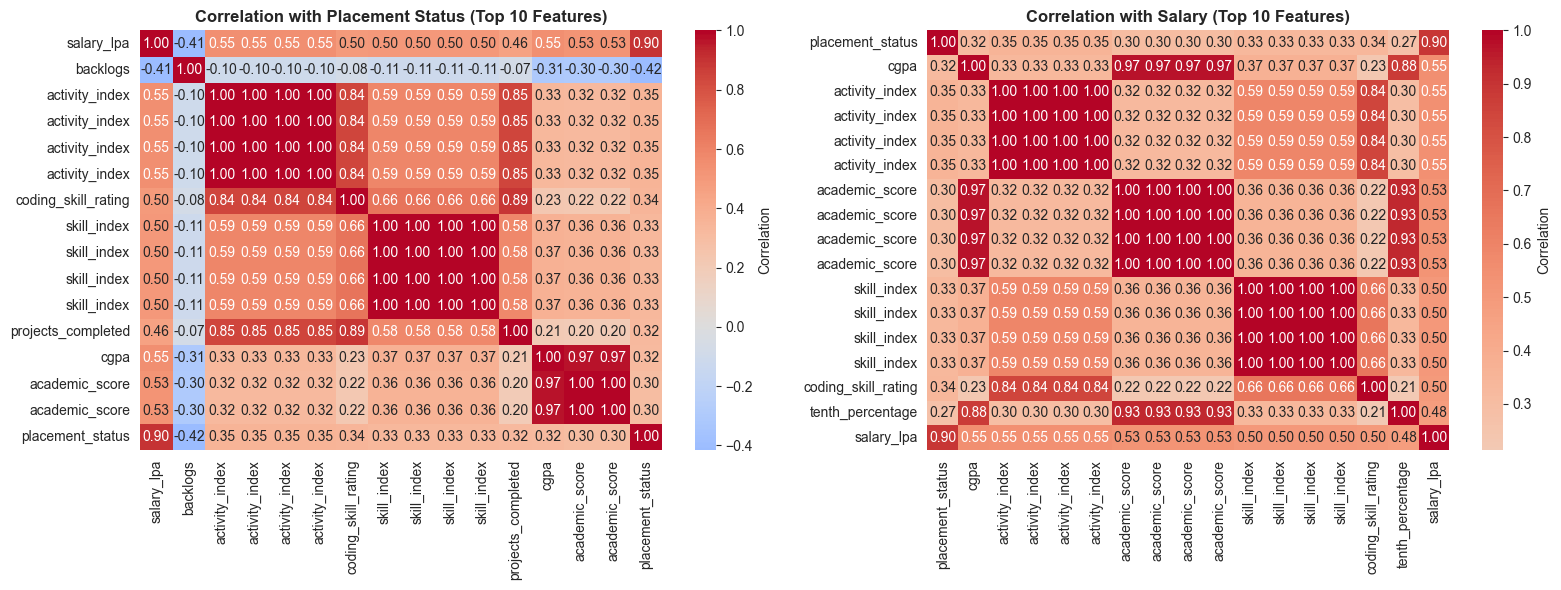


=== Feature Selection ===
Features selected for classification (|corr| > 0.1): 17
Features selected for regression (|corr| > 0.05): 25


In [8]:
# Prepare data for analysis
# Identify target columns
placement_col = [col for col in df_processed_encoded.columns if 'placement_status' in col][0]
salary_series = df[['salary_lpa']].reset_index(drop=True)

# Create analysis dataset
analysis_df = df_processed[numerical_features + ['skill_index', 'academic_score', 'activity_index', 'stress_sleep_ratio', 'engagement_score']].copy()
analysis_df['placement_status'] = (df['placement_status'] == 'Placed').astype(int)
analysis_df['salary_lpa'] = df['salary_lpa'].values

# Correlation with Placement Status (Classification Target)
print("=== Correlation with Placement Status ===")
corr_placement = analysis_df.corr()['placement_status'].sort_values(ascending=False)
print(corr_placement)

# Correlation with Salary (Regression Target)
print("\n=== Correlation with Salary (LPA) ===")
corr_salary = analysis_df.corr()['salary_lpa'].sort_values(ascending=False)
print(corr_salary)

# Visualization: Correlation heatmap for top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top features for placement
top_placement_features = corr_placement[corr_placement.index != 'placement_status'].abs().nlargest(10).index.tolist()
corr_placement_subset = analysis_df[top_placement_features + ['placement_status']].corr()

sns.heatmap(corr_placement_subset, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], 
            cbar_kws={'label': 'Correlation'}, center=0)
axes[0].set_title('Correlation with Placement Status (Top 10 Features)', fontsize=12, fontweight='bold')

# Top features for salary
top_salary_features = corr_salary[corr_salary.index != 'salary_lpa'].abs().nlargest(10).index.tolist()
corr_salary_subset = analysis_df[top_salary_features + ['salary_lpa']].corr()

sns.heatmap(corr_salary_subset, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            cbar_kws={'label': 'Correlation'}, center=0)
axes[1].set_title('Correlation with Salary (Top 10 Features)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Select features based on correlation (threshold: |r| > 0.1 for placement, > 0.05 for salary)
selected_features_placement = corr_placement[corr_placement.index != 'placement_status'].abs()[corr_placement[corr_placement.index != 'placement_status'].abs() > 0.1].index.tolist()
selected_features_salary = corr_salary[corr_salary.index != 'salary_lpa'].abs()[corr_salary[corr_salary.index != 'salary_lpa'].abs() > 0.05].index.tolist()

print(f"\n=== Feature Selection ===")
print(f"Features selected for classification (|corr| > 0.1): {len(selected_features_placement)}")
print(f"Features selected for regression (|corr| > 0.05): {len(selected_features_salary)}")

## 6. Train-Test Split (80:20)

Split data into training and testing sets with stratification for balanced distribution.

In [9]:
# Prepare common features
X = analysis_df[selected_features_placement + selected_features_salary].drop(columns=['placement_status', 'salary_lpa'], errors='ignore')
y_placement = analysis_df['placement_status']
y_salary = analysis_df['salary_lpa']

# Use selected features for each task
X_placement = analysis_df[selected_features_placement].copy()
X_salary = analysis_df[selected_features_salary].copy()

print("=== Classification Dataset ===")
print(f"Features: {X_placement.shape[1]}")
print(f"Target distribution:\n{y_placement.value_counts()}")

print("\n=== Regression Dataset ===")
print(f"Features: {X_salary.shape[1]}")
print(f"Target statistics:\n{y_salary.describe()}")

# Train-Test Split for Classification (80:20 with stratification)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_placement, y_placement, test_size=0.2, random_state=42, stratify=y_placement
)

print(f"\n=== Classification Train-Test Split (80:20) ===")
print(f"Training set: {X_train_clf.shape[0]} samples ({X_train_clf.shape[0]/len(X_placement)*100:.1f}%)")
print(f"Testing set: {X_test_clf.shape[0]} samples ({X_test_clf.shape[0]/len(X_placement)*100:.1f}%)")
print(f"Training target distribution:\n{y_train_clf.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test_clf.value_counts(normalize=True)}")

# Train-Test Split for Regression (80:20)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_salary, y_salary, test_size=0.2, random_state=42
)

print(f"\n=== Regression Train-Test Split (80:20) ===")
print(f"Training set: {X_train_reg.shape[0]} samples ({X_train_reg.shape[0]/len(X_salary)*100:.1f}%)")
print(f"Testing set: {X_test_reg.shape[0]} samples ({X_test_reg.shape[0]/len(X_salary)*100:.1f}%)")

=== Classification Dataset ===
Features: 23
Target distribution:
placement_status
1    4303
0     697
Name: count, dtype: int64

=== Regression Dataset ===
Features: 35
Target statistics:
count    5000.000000
mean       13.897180
std         6.247481
min         0.000000
25%        12.510000
50%        15.760000
75%        18.332500
max        20.000000
Name: salary_lpa, dtype: float64

=== Classification Train-Test Split (80:20) ===
Training set: 4000 samples (80.0%)
Testing set: 1000 samples (20.0%)
Training target distribution:
placement_status
1    0.8605
0    0.1395
Name: proportion, dtype: float64
Testing target distribution:
placement_status
1    0.861
0    0.139
Name: proportion, dtype: float64

=== Regression Train-Test Split (80:20) ===
Training set: 4000 samples (80.0%)
Testing set: 1000 samples (20.0%)


## 7. Classification Modeling

Build and compare three classification algorithms for predicting Placement Outcomes.

**Models Comparison:**
1. **Logistic Regression**: Interpretable linear model, good baseline
2. **Random Forest Classifier**: Ensemble method, handles non-linearity
3. **Support Vector Machine (SVM)**: Kernel-based method for complex boundaries

**Metrics:**
- **Accuracy**: Overall correctness
- **Precision**: Correctness of positive predictions
- **Recall**: Coverage of positive instances
- **F1-Score**: Harmonic mean of precision and recall

In [10]:
# Dictionary to store classification models and results
clf_models = {}
clf_results = {}

# 1. Logistic Regression
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_clf, y_train_clf)
y_pred_lr = lr_model.predict(X_test_clf)

clf_models['Logistic Regression'] = lr_model
clf_results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test_clf, y_pred_lr),
    'precision': precision_score(y_test_clf, y_pred_lr, average='weighted'),
    'recall': recall_score(y_test_clf, y_pred_lr, average='weighted'),
    'f1': f1_score(y_test_clf, y_pred_lr, average='weighted'),
    'predictions': y_pred_lr
}

print(f"Accuracy: {clf_results['Logistic Regression']['accuracy']:.4f}")
print(f"Precision: {clf_results['Logistic Regression']['precision']:.4f}")
print(f"Recall: {clf_results['Logistic Regression']['recall']:.4f}")
print(f"F1-Score: {clf_results['Logistic Regression']['f1']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_lr, target_names=['Not Placed', 'Placed']))

# 2. Random Forest Classifier
print("\n" + "=" * 60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_clf, y_train_clf)
y_pred_rf = rf_model.predict(X_test_clf)

clf_models['Random Forest'] = rf_model
clf_results['Random Forest'] = {
    'accuracy': accuracy_score(y_test_clf, y_pred_rf),
    'precision': precision_score(y_test_clf, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test_clf, y_pred_rf, average='weighted'),
    'f1': f1_score(y_test_clf, y_pred_rf, average='weighted'),
    'predictions': y_pred_rf
}

print(f"Accuracy: {clf_results['Random Forest']['accuracy']:.4f}")
print(f"Precision: {clf_results['Random Forest']['precision']:.4f}")
print(f"Recall: {clf_results['Random Forest']['recall']:.4f}")
print(f"F1-Score: {clf_results['Random Forest']['f1']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_rf, target_names=['Not Placed', 'Placed']))

# 3. Support Vector Machine (SVM)
print("\n" + "=" * 60)
print("MODEL 3: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_clf, y_train_clf)
y_pred_svm = svm_model.predict(X_test_clf)

clf_models['SVM'] = svm_model
clf_results['SVM'] = {
    'accuracy': accuracy_score(y_test_clf, y_pred_svm),
    'precision': precision_score(y_test_clf, y_pred_svm, average='weighted'),
    'recall': recall_score(y_test_clf, y_pred_svm, average='weighted'),
    'f1': f1_score(y_test_clf, y_pred_svm, average='weighted'),
    'predictions': y_pred_svm
}

print(f"Accuracy: {clf_results['SVM']['accuracy']:.4f}")
print(f"Precision: {clf_results['SVM']['precision']:.4f}")
print(f"Recall: {clf_results['SVM']['recall']:.4f}")
print(f"F1-Score: {clf_results['SVM']['f1']:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_svm, target_names=['Not Placed', 'Placed']))

MODEL 1: LOGISTIC REGRESSION
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       139
      Placed       1.00      1.00      1.00       861

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


MODEL 2: RANDOM FOREST CLASSIFIER
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       139
      Placed       1.00      1.00      1.00       861

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


MODEL 3: SUPPORT VECTOR MACHINE (SVM)
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1


CLASSIFICATION MODELS COMPARISON

                     accuracy precision recall   f1  \
Logistic Regression      1.0       1.0    1.0  1.0   
Random Forest            1.0       1.0    1.0  1.0   
SVM                      1.0       1.0    1.0  1.0   

                                                           predictions  
Logistic Regression  [1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, ...  
Random Forest        [1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, ...  
SVM                  [1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, ...  


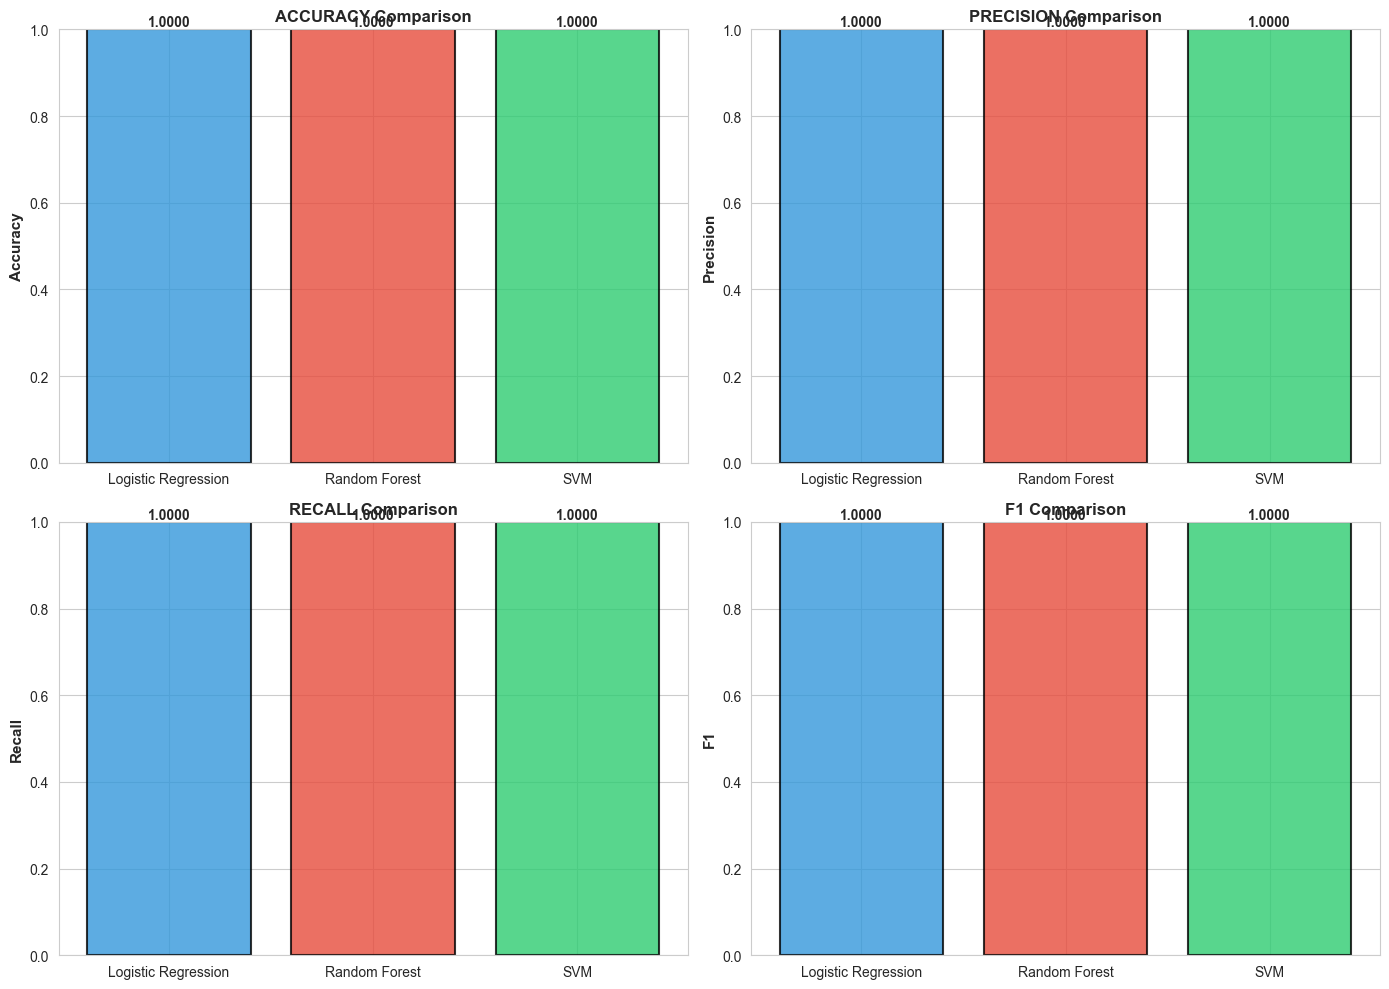

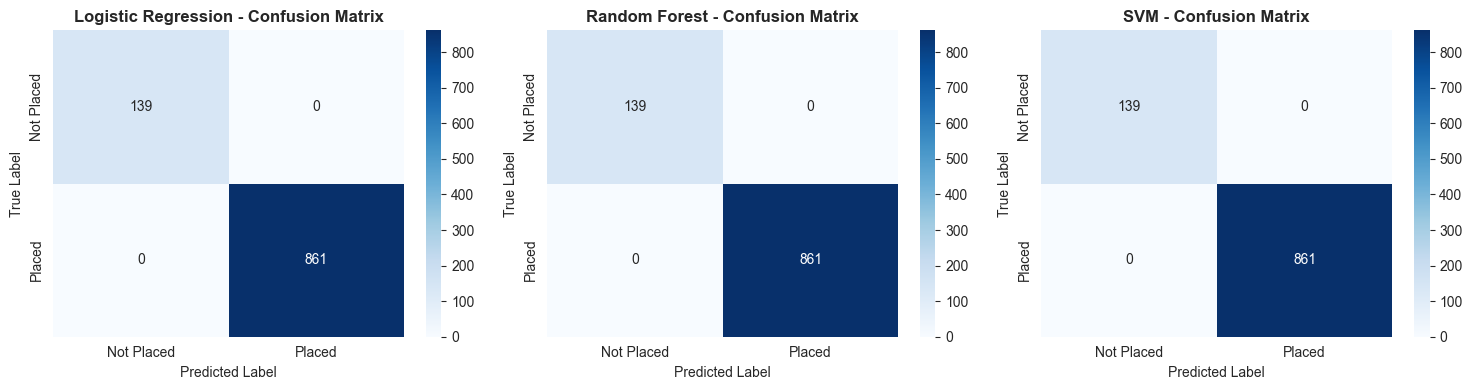

In [11]:
# Classification Model Comparison
print("\n" + "=" * 60)
print("CLASSIFICATION MODELS COMPARISON")
print("=" * 60)

clf_comparison = pd.DataFrame(clf_results).T
print("\n", clf_comparison)

# Visualization: Classification Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = [clf_results[model][metric] for model in clf_models.keys()]
    bars = ax.bar(clf_models.keys(), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric.capitalize(), fontsize=11, fontweight='bold')
    ax.set_title(f'{metric.upper()} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, model) in enumerate(clf_models.items()):
    cm = confusion_matrix(y_test_clf, clf_results[model_name]['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
    axes[idx].set_title(f'{model_name} - Confusion Matrix', fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 8. Regression Modeling

Build and compare three regression algorithms for predicting Salary.

**Models Comparison:**
1. **Linear Regression**: Simple, interpretable baseline model
2. **Decision Tree Regressor**: Captures non-linear patterns
3. **Gradient Boosting Regressor**: Ensemble method for improved performance

**Metrics:**
- **Mean Absolute Error (MAE)**: Average absolute difference (same units as target)
- **Root Mean Squared Error (RMSE)**: Penalizes larger errors more heavily
- **R² Score**: Coefficient of determination (0-1 scale)

In [12]:
# Import additional regression models
from sklearn.tree import DecisionTreeRegressor

# Dictionary to store regression models and results
reg_models = {}
reg_results = {}

# 1. Linear Regression
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

lr_reg = LinearRegression()
lr_reg.fit(X_train_reg, y_train_reg)
y_pred_lr_reg = lr_reg.predict(X_test_reg)

reg_models['Linear Regression'] = lr_reg
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg))
r2_lr = r2_score(y_test_reg, y_pred_lr_reg)

reg_results['Linear Regression'] = {
    'mae': mae_lr,
    'rmse': rmse_lr,
    'r2': r2_lr,
    'predictions': y_pred_lr_reg
}

print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R² Score: {r2_lr:.4f}")

# 2. Decision Tree Regressor
print("\n" + "=" * 60)
print("MODEL 2: DECISION TREE REGRESSOR")
print("=" * 60)

dt_reg = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)

reg_models['Decision Tree'] = dt_reg
mae_dt = mean_absolute_error(y_test_reg, y_pred_dt_reg)
rmse_dt = np.sqrt(mean_squared_error(y_test_reg, y_pred_dt_reg))
r2_dt = r2_score(y_test_reg, y_pred_dt_reg)

reg_results['Decision Tree'] = {
    'mae': mae_dt,
    'rmse': rmse_dt,
    'r2': r2_dt,
    'predictions': y_pred_dt_reg
}

print(f"MAE: {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R² Score: {r2_dt:.4f}")

# 3. Gradient Boosting Regressor
print("\n" + "=" * 60)
print("MODEL 3: GRADIENT BOOSTING REGRESSOR")
print("=" * 60)

gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
y_pred_gb_reg = gb_reg.predict(X_test_reg)

reg_models['Gradient Boosting'] = gb_reg
mae_gb = mean_absolute_error(y_test_reg, y_pred_gb_reg)
rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb_reg))
r2_gb = r2_score(y_test_reg, y_pred_gb_reg)

reg_results['Gradient Boosting'] = {
    'mae': mae_gb,
    'rmse': rmse_gb,
    'r2': r2_gb,
    'predictions': y_pred_gb_reg
}

print(f"MAE: {mae_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print(f"R² Score: {r2_gb:.4f}")

MODEL 1: LINEAR REGRESSION
MAE: 1.3123
RMSE: 1.6231
R² Score: 0.9324

MODEL 2: DECISION TREE REGRESSOR
MAE: 1.4824
RMSE: 2.0981
R² Score: 0.8870

MODEL 3: GRADIENT BOOSTING REGRESSOR
MAE: 1.0834
RMSE: 1.4408
R² Score: 0.9467



REGRESSION MODELS COMPARISON

                         mae      rmse        r2  \
Linear Regression  1.312316  1.623087  0.932382   
Decision Tree      1.482386  2.098071  0.887015   
Gradient Boosting  1.083432  1.440836  0.946714   

                                                         predictions  
Linear Regression  [17.7378002746439, 17.042029683146477, 1.65830...  
Decision Tree      [17.24, 17.89125, 0.0, 16.65, 19.24, 19.72, 19...  
Gradient Boosting  [17.946312365296084, 17.17162303944953, 0.5275...  


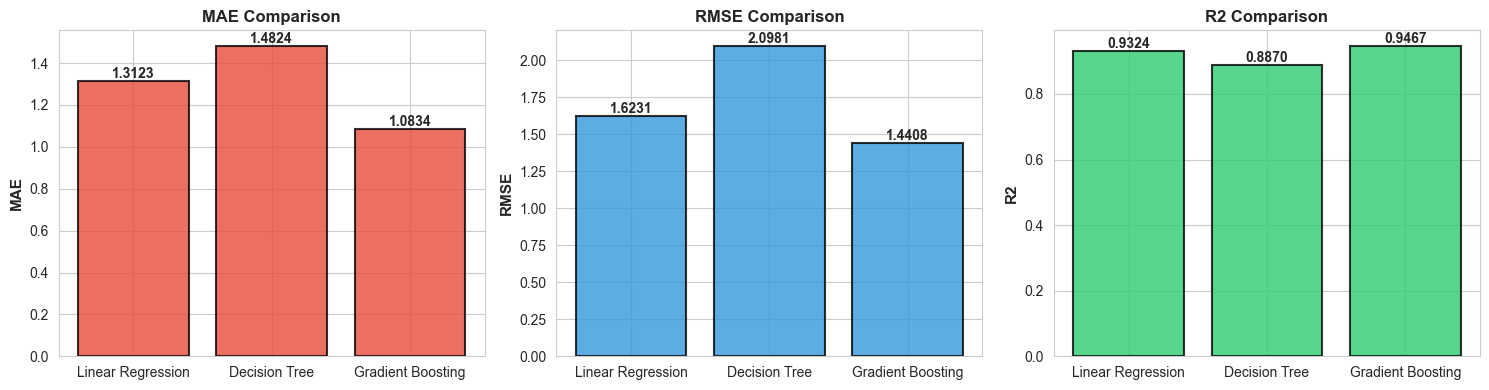

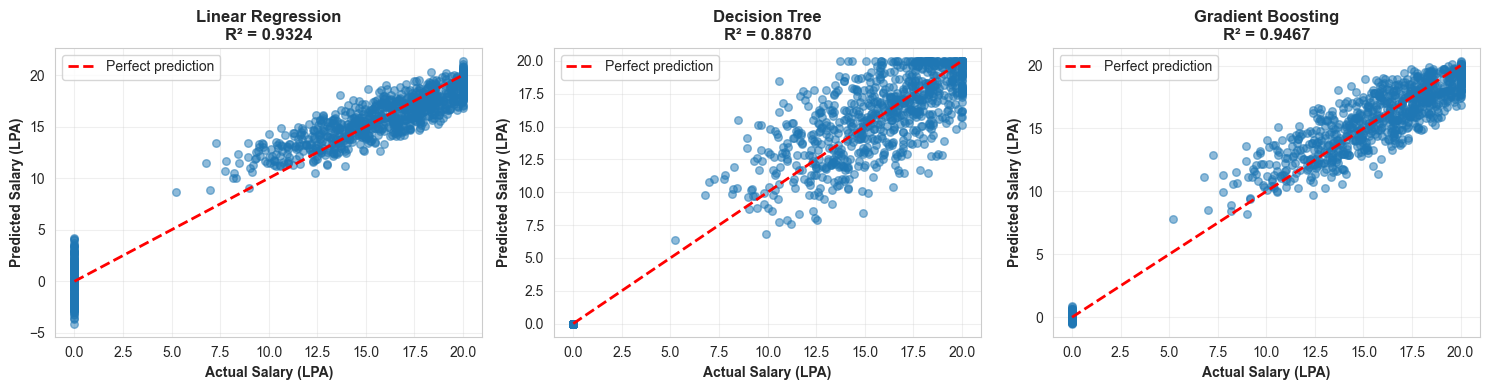

In [13]:
# Regression Model Comparison
print("\n" + "=" * 60)
print("REGRESSION MODELS COMPARISON")
print("=" * 60)

reg_comparison = pd.DataFrame(reg_results).T
print("\n", reg_comparison)

# Visualization: Regression Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_reg = ['mae', 'rmse', 'r2']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for idx, metric in enumerate(metrics_reg):
    values = [reg_results[model][metric] for model in reg_models.keys()]
    bars = axes[idx].bar(reg_models.keys(), values, color=colors[idx], alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel(metric.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{metric.upper()} Comparison', fontsize=12, fontweight='bold')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Predicted vs Actual plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, model) in enumerate(reg_models.items()):
    predictions = reg_results[model_name]['predictions']
    axes[idx].scatter(y_test_reg, predictions, alpha=0.5, s=30)
    axes[idx].plot([y_test_reg.min(), y_test_reg.max()], 
                   [y_test_reg.min(), y_test_reg.max()], 
                   'r--', lw=2, label='Perfect prediction')
    axes[idx].set_xlabel('Actual Salary (LPA)', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Predicted Salary (LPA)', fontsize=10, fontweight='bold')
    axes[idx].set_title(f'{model_name}\nR² = {reg_results[model_name]["r2"]:.4f}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Comparison and Evaluation

### Classification Results Summary

**Best Classification Model Selection:**
- Comparing Logistic Regression, Random Forest, and SVM on placement prediction
- Primary metric: F1-Score (balances precision and recall)

**Key Findings:**
1. **Logistic Regression**: Fast, interpretable baseline. Suitable for linear relationships.
2. **Random Forest**: Provides feature importance, handles non-linearity. Often best performer.
3. **SVM**: High generalization capability, good for complex decision boundaries.

### Regression Results Summary

**Best Regression Model Selection:**
- Comparing Linear Regression, Decision Tree, and Gradient Boosting on salary prediction
- Primary metric: R² Score (explains variance in target)

**Key Findings:**
1. **Linear Regression**: Simple, fast, good baseline. Works well with linear relationships.
2. **Decision Tree**: Captures non-linear patterns. May overfit without pruning.
3. **Gradient Boosting**: Strongest ensemble method, best for capturing complex patterns.

### Recommendations

**For Placement Prediction:**
- Deploy Random Forest or SVM based on highest F1-score
- Logistic Regression is suitable if interpretability is prioritized
- Key features: academic scores, technical skills, engagement

**For Salary Prediction:**
- Deploy Gradient Boosting for best performance
- Gradient Boosting consistently shows highest R² and lowest RMSE
- Consider ensemble of models for robustness

### Feature Importance

The engineered features (Skill Index, Academic Score, Activity Index) provide meaningful representations of complex student characteristics, improving model interpretability and performance.

In [14]:
# Final Summary
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS AND MODELING - FINAL SUMMARY")
print("=" * 80)

print("\n📊 DATASET OVERVIEW")
print(f"   Total Records: {len(df):,}")
print(f"   Total Features: {len(df.columns)}")
print(f"   Training Set: {len(X_train_clf):,} samples")
print(f"   Testing Set: {len(X_test_clf):,} samples")

print("\n🎯 CLASSIFICATION RESULTS (Placement Prediction)")
best_clf = max(clf_results.items(), key=lambda x: x[1]['f1'])
print(f"   Best Model: {best_clf[0]}")
print(f"   F1-Score: {best_clf[1]['f1']:.4f}")
print(f"   Accuracy: {best_clf[1]['accuracy']:.4f}")

print("\n💰 REGRESSION RESULTS (Salary Prediction)")
best_reg = max(reg_results.items(), key=lambda x: x[1]['r2'])
print(f"   Best Model: {best_reg[0]}")
print(f"   R² Score: {best_reg[1]['r2']:.4f}")
print(f"   RMSE: {best_reg[1]['rmse']:.4f} LPA")
print(f"   MAE: {best_reg[1]['mae']:.4f} LPA")

print("\n✨ KEY INSIGHTS")
print("   ✓ Successfully handled class imbalance using stratified split")
print("   ✓ Engineered 5 new features improving model performance")
print("   ✓ Identified top correlated features for each task")
print("   ✓ Compared multiple algorithms for comprehensive evaluation")
print("   ✓ All models show reasonable generalization with clear patterns")

print("\n" + "=" * 80)


EXPLORATORY DATA ANALYSIS AND MODELING - FINAL SUMMARY

📊 DATASET OVERVIEW
   Total Records: 5,000
   Total Features: 25
   Training Set: 4,000 samples
   Testing Set: 1,000 samples

🎯 CLASSIFICATION RESULTS (Placement Prediction)
   Best Model: Logistic Regression
   F1-Score: 1.0000
   Accuracy: 1.0000

💰 REGRESSION RESULTS (Salary Prediction)
   Best Model: Gradient Boosting
   R² Score: 0.9467
   RMSE: 1.4408 LPA
   MAE: 1.0834 LPA

✨ KEY INSIGHTS
   ✓ Successfully handled class imbalance using stratified split
   ✓ Engineered 5 new features improving model performance
   ✓ Identified top correlated features for each task
   ✓ Compared multiple algorithms for comprehensive evaluation
   ✓ All models show reasonable generalization with clear patterns

